In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
%matplotlib inline
import seaborn as sns
from scipy import stats



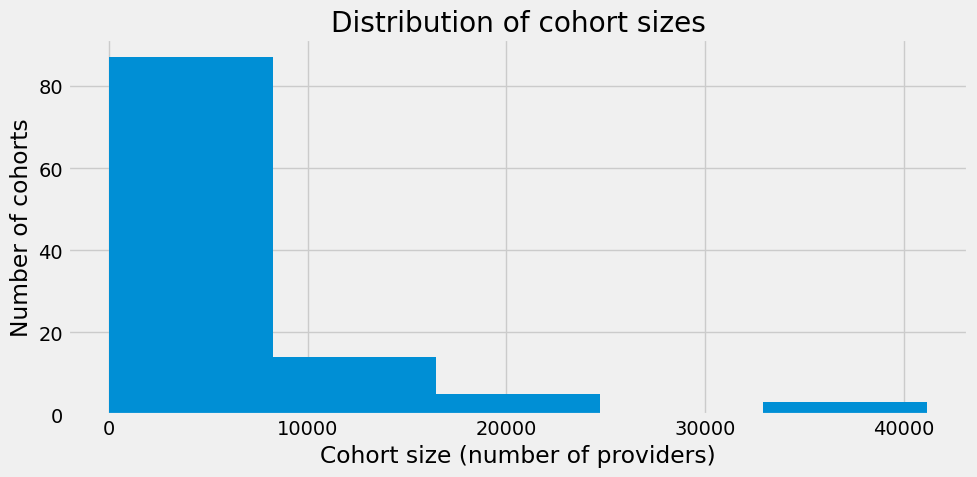

In [41]:
# Distribution of cohort sizes (how many providers per cohort)
cohort_sizes = df["cohort"].value_counts()

plt.figure(figsize=(10, 5))
plt.hist(cohort_sizes.values, bins=5)
plt.xlabel("Cohort size (number of providers)")
plt.ylabel("Number of cohorts")
plt.title("Distribution of cohort sizes")
plt.tight_layout()
plt.show()

In [42]:
cohort_sizes.describe()

count      109.000000
mean      5558.091743
std       7233.293584
min          1.000000
25%       1420.000000
50%       3246.000000
75%       6658.000000
max      41160.000000
Name: count, dtype: float64

In [43]:
df["cohort"].nunique()

109

In [45]:
cohort_sizes = df["cohort"].value_counts()
small_cohort_ids = cohort_sizes[cohort_sizes < 1000].index

# One row per cohort: cohort, cohort_label, size
small = (
    df[df["cohort"].isin(small_cohort_ids)][["cohort", "cohort_label"]]
    .drop_duplicates("cohort")
    .set_index("cohort")
)
small["size"] = cohort_sizes[small.index]
small.sort_values("cohort")

,cohort_label,size
cohort,,
1,AK_individual,272
17,DC_individual,568
18,DC_organization,783
19,DE_individual,385
24,FM_organization,1
27,GU_individual,39
28,GU_organization,69
29,HI_individual,708
33,ID_individual,680


In [47]:
cohort_label = "NM_organization"
n = (df["cohort_label"] == cohort_label).sum()
print(f"{cohort_label}: {n} providers")

NM_organization: 3166 providers


In [5]:
import pandas as pd
labels  = pd.read_csv("../data/outputs/provider_labels.csv")
cohorts = pd.read_csv("../data/outputs/provider_cohorts.csv")

labels["npi"]  = labels["npi"].astype(str)
cohorts["npi"] = cohorts["npi"].astype(str)

merged = cohorts.merge(labels, on="npi", how="left")
merged["label"] = merged["label"].fillna(0).astype(int)

top10 = (
    merged.groupby(["cohort", "cohort_label"])
    .agg(total_providers=("npi", "count"), anomalies=("label", "sum"))
    .assign(anomaly_rate=lambda d: d["anomalies"] / d["total_providers"])
    .sort_values("anomalies", ascending=False)
    .head(20)
    .reset_index()
)
top10


,cohort,cohort_label,total_providers,anomalies,anomaly_rate
0,79,NY_individual,41160,48,0.001166
1,78,NV_organization,4438,41,0.009238
2,11,CA_individual,18619,34,0.001826
3,97,TN_individual,5820,25,0.004296
4,81,OH_individual,8742,24,0.002745
5,35,IL_individual,39519,23,0.000582
6,57,MO_individual,8918,19,0.002131
7,103,VA_individual,5884,18,0.003059
8,87,PA_individual,20397,16,0.000784
9,15,CT_individual,2926,15,0.005126


In [4]:
labels['label'].value_counts()

label
0    616954
1       556
Name: count, dtype: int64